# TensorFlow Playground: Guía Práctica

[TensorFlow Playground](https://playground.tensorflow.org/) es una aplicación web que te permite configurar una pequeña red neuronal y **verla aprender en tiempo real** con datasets 2D sintéticos.

Este notebook recorre una serie de experimentos que puedes ejecutar en el Playground, cada uno ilustrando un concepto clave. Para cada experimento también mostramos el código PyTorch equivalente para que puedas conectar la intuición visual con la implementación real.

> **Cómo usar este notebook:** abre [playground.tensorflow.org](https://playground.tensorflow.org/) en una pestaña separada y sigue las instrucciones del experimento. Luego ejecuta las celdas de PyTorch para ver el mismo comportamiento en código.

## Controles del Playground

| Control | Qué hace |
|---------|---------|
| **Dataset** (panel izquierdo) | Elige un patrón: dos grupos, círculo, XOR, espiral |
| **Features** | Activa o desactiva transformaciones de entrada: $x_1^2$, $x_2^2$, $x_1 \times x_2$, sin, cos |
| **Hidden layers** | Agrega o quita capas y neuronas por capa |
| **Activation** | ReLU, Tanh, Sigmoid o Linear |
| **Learning rate** | Tamaño del paso para el Optimizer |
| **Regularization** | None, L1 o L2 (con control deslizante de intensidad) |
| **Problem type** | Clasificación o Regresión |
| **Play / Pause / Reset** | Controla el entrenamiento |

El fondo de colores muestra la **frontera de decisión**: azul donde la red predice una clase, naranja para la otra. El grosor de las líneas entre neuronas indica la magnitud del Weight.

## Experimento 1: separación lineal (una neurona)

**Configuración en el Playground:**
1. Selecciona el dataset de **dos grupos**.
2. Usa solo las entradas X₁ y X₂ (sin características extra).
3. Elimina todas las Hidden Layers — solo una conexión directa a la salida.
4. Presiona Play.

**Qué deberías ver:** una línea recta se ajusta gradualmente para separar los puntos azules y naranjas. La Loss baja hasta casi cero.

**Idea clave:** una sola neurona = un clasificador lineal. Solo puede trazar **una frontera recta**.

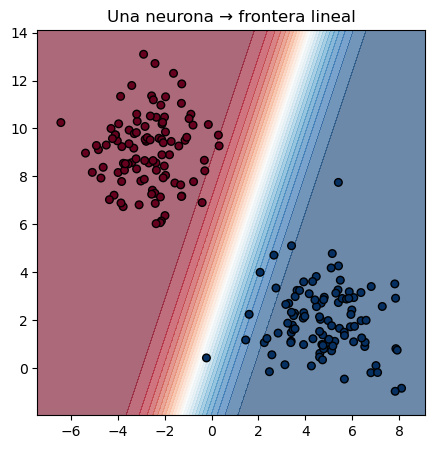

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Equivalente: una neurona para datos linealmente separables
X, y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)
X_t = torch.FloatTensor(X)
y_t = torch.FloatTensor(y).unsqueeze(1)

model = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
criterion = nn.BCELoss()

for _ in range(200):
    optimizer.zero_grad()
    criterion(model(X_t), y_t).backward()
    optimizer.step()

# Graficar la frontera de decisión
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with torch.no_grad():
    Z = model(grid).reshape(xx.shape).numpy()

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, levels=25, cmap="RdBu", alpha=0.6)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolors="k", s=30)
plt.title("Una neurona → frontera lineal")
plt.show()

## Experimento 2: los datos no lineales requieren Hidden Layers

**Configuración en el Playground:**
1. Selecciona el dataset de **círculo**.
2. Empieza sin Hidden Layers y presiona Play. Observa que una sola neurona **falla**.
3. Agrega una Hidden Layer con **4 neuronas** (Activation ReLU o Tanh).
4. Reinicia y presiona Play de nuevo.

**Qué deberías ver:** con la Hidden Layer, la frontera se curva alrededor del círculo interior. Sin ella, el modelo está atascado trazando una línea recta.

**Idea clave:** las Hidden Layers + Activation Functions permiten fronteras de decisión no lineales.

In [ ]:
from sklearn.datasets import make_circles

X_c, y_c = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=42)
X_ct = torch.FloatTensor(X_c)
y_ct = torch.FloatTensor(y_c).unsqueeze(1)

# Modelo con Hidden Layer
model = nn.Sequential(
    nn.Linear(2, 4), nn.ReLU(),
    nn.Linear(4, 1), nn.Sigmoid(),
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
criterion = nn.BCELoss()

for _ in range(500):
    optimizer.zero_grad()
    criterion(model(X_ct), y_ct).backward()
    optimizer.step()

xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with torch.no_grad():
    Z = model(grid).reshape(xx.shape).numpy()

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, levels=25, cmap="RdBu", alpha=0.6)
plt.scatter(X_c[:, 0], X_c[:, 1], c=y_c, cmap="RdBu", edgecolors="k", s=20)
plt.title("Hidden Layer → frontera no lineal")
plt.show()

## Experimento 3: Activation Functions

**Configuración en el Playground:**
1. Usa el dataset **XOR** con 1 Hidden Layer (4 neuronas).
2. Prueba cada Activation: **ReLU**, **Tanh**, **Sigmoid**, **Linear**.
3. Compara la velocidad de convergencia y la forma de la frontera final.

**Resultados esperados:**
- **ReLU / Tanh**: convergen relativamente rápido, buena frontera no lineal.
- **Sigmoid**: puede ser más lento por saturación (los gradientes se reducen para entradas extremas).
- **Linear**: **falla** — linear(linear) = linear, no se introduce no-linealidad.

**Idea clave:** la Activation Function es lo que rompe la linealidad. Sin ella, agregar capas no sirve de nada.

In [ ]:
# Comparar Activations en XOR
from sklearn.datasets import make_moons

X_m, y_m = make_moons(n_samples=300, noise=0.15, random_state=42)
X_mt = torch.FloatTensor(X_m)
y_mt = torch.FloatTensor(y_m).unsqueeze(1)

activations = {"ReLU": nn.ReLU(), "Tanh": nn.Tanh(), "Sigmoid": nn.Sigmoid()}
histories = {}

for name, act in activations.items():
    model = nn.Sequential(nn.Linear(2, 8), act, nn.Linear(8, 1))
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    crit = nn.BCEWithLogitsLoss()
    losses = []
    for _ in range(300):
        opt.zero_grad()
        loss = crit(model(X_mt), y_mt)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    histories[name] = losses

plt.figure(figsize=(8, 4))
for name, losses in histories.items():
    plt.plot(losses, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparación de Activation Functions")
plt.legend()
plt.show()

## Experimento 4: ingeniería de características

**Configuración en el Playground:**
1. Selecciona el dataset **XOR**.
2. Activa la característica **x₁ × x₂**. Elimina todas las Hidden Layers.
3. Presiona Play.

**Qué deberías ver:** ¡el XOR se resuelve con una sola neurona! La característica de multiplicación transforma el problema en algo linealmente separable.

**Idea clave:** a veces una característica de entrada bien elegida puede reemplazar toda una Hidden Layer. En Deep Learning, la red *aprende* estas transformaciones automáticamente — pero a veces añadir características específicas del dominio ayuda.

Consulta ➜ [complementary/xor_linearity.ipynb](xor_linearity.ipynb) para una exploración detallada.

## Experimento 5: Learning Rate

**Configuración en el Playground:**
1. Usa el dataset de **círculo** con 1 Hidden Layer (4 neuronas, Tanh).
2. Prueba Learning Rates: **0.001**, **0.03**, **1.0**.
3. Observa la velocidad y estabilidad del entrenamiento.

| LR | Efecto |
|----|--------|
| **0.001** | Convergencia muy lenta — la Loss apenas se mueve |
| **0.03** | Convergencia estable y progresiva |
| **1.0** | La Loss oscila descontroladamente o diverge |

**Idea clave:** el Learning Rate es el hiperparámetro más importante a ajustar. Demasiado alto → inestable. Demasiado bajo → desperdicia tiempo.

## Experimento 6: Overfitting y regularización

**Configuración en el Playground:**
1. Selecciona el dataset de **espiral** con **alto ruido**.
2. Usa una red grande: 2 Hidden Layers, 8 neuronas cada una, ReLU.
3. Entrena sin regularización — observa la frontera irregular.
4. Ahora aplica **regularización L2** (intensidad ~0.1) — la frontera se suaviza.

**Qué está pasando:** sin regularización, el modelo ajusta cada punto ruidoso. L2 penaliza los Weights grandes, forzando fronteras más simples (suaves).

Consulta ➜ [04_training_dynamics.ipynb](../04_training_dynamics.ipynb) para profundizar en regularización.

## Desafío: resolver la espiral

**Tarea:** configura una red en TensorFlow Playground que separe limpiamente el dataset de **espiral**.

**Pistas:**
1. Probablemente necesitarás **2–3 Hidden Layers** con **6–8 neuronas** cada una.
2. **ReLU** tiende a funcionar bien aquí.
3. Un Learning Rate moderado (0.01–0.03) es un buen punto de partida.
4. Si la frontera es demasiado irregular, agrega algo de regularización L2.

**Reflexiona:** ¿cuál fue la arquitectura más simple que funcionó? ¿Cómo afectaron el Learning Rate y la regularización al resultado?

## Resumen

| Concepto | Experimento en el Playground | Conclusión |
|---------|------------------------------|------------|
| Clasificador lineal | Una neurona, dos grupos | Una sola neurona traza una línea recta |
| No-linealidad | Dataset círculo + Hidden Layer | Las Hidden Layers permiten fronteras curvas |
| Activation Functions | XOR + distintas Activations | La Activation no lineal es esencial |
| Ingeniería de características | XOR + característica x₁×x₂ | Buenas características pueden reemplazar complejidad del modelo |
| Learning Rate | Círculo + LR variable | El hiperparámetro más importante |
| Regularización | Espiral + L2 | Previene Overfitting, suaviza las fronteras |

Todos estos conceptos se traducen directamente a modelos reales en PyTorch — el Playground solo los hace visibles.